In [4]:
"""
This script was written and tested with Python 3.10.6, and may not work with other versions of Python.

The script is accompanying the manuscript: "Chromosome topology gates productive homology search" by Tišma et al.

This code is used to calculate the average supercoiling density of surface-bound DNA molecules.

Author(s):
    Miloš Tišma, Joseph J. Loparo
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import pandas as pd

In [5]:
# McGhee-von Hippel for finite conc (analytical solver via fsolve)
def mv_h_finite_conc_model(K, n, cons_DNA, cons_dye):
    """
    Compute fractional binding gamma using MvH model for open DNA (zero torque).
    INPUTS:
    - K: association constant (1/M)
    - n: binding site size (bp)
    - cons_DNA: array of DNA conc (M * bp)
    - cons_dye: scalar dye conc (M)
    OUTPUT:
    - gamma_out: array of gamma (bound dyes per bp)
    """
    def mvh_eq(gamma, free_ligand, K, n):
        if gamma >= 1/n:
            return 1e6 # Invalid
        site_factor = ((1 - n * gamma) / (1 - (n - 1) * gamma)) ** (n - 1) if n > 1 else 1
        return gamma - K * free_ligand * (1 - n * gamma) * site_factor
    gamma_out = np.zeros(len(cons_DNA))
    for i, c_dna in enumerate(cons_DNA):
        def eq(gamma):
            free_ligand = cons_dye - gamma * c_dna # Bound ligand = gamma * c_dna
            if free_ligand < 0:
                return 1e6
            return mvh_eq(gamma, free_ligand, K, n)
        gamma_sol = fsolve(eq, 0.01)[0] # Solve gamma - f(gamma) = 0
        gamma_out[i] = max(0, min(1/n, gamma_sol)) # Clamp
    return gamma_out

# Main model: plasmid_dye_binding_model (iterative solver for SC)
def plasmid_dye_binding_model(K, n, delta_Tw_deg, deltaz_dye, Nbp, C, initial_dLk, cons_DNA_bp, cons_dye, force=0):
    """
    Predict binding to supercoiled plasmid (torsionally constrained).
    Iterative solve for N_bound under torque (from Kolbeck et al., NAR 2024).
    INPUTS:
    - K: association const (1/M)
    - n: site size (bp)
    - delta_Tw_deg: unwinding angle per dye (degrees)
    - deltaz_dye: elongation per dye (nm)
    - Nbp: base pairs
    - C: torsional stiffness (nm)
    - initial_dLk: initial linking diff (turns)
    - cons_DNA_bp: DNA conc (M * bp)
    - cons_dye: dye conc (M)
    - force: applied force (pN, default 0)
    OUTPUT:
    - N_bound: bound dyes per plasmid
    - DeltaTw: twist change (turns)
    - Torque: equilibrium torque (pN.nm)
    """
    kT = 4.1 # pN.nm
    delta_theta = np.deg2rad(delta_Tw_deg) # radians per dye
    L0 = 0.34 * Nbp # Initial contour length (nm)
    omega_tw = 0.2 # Twist fraction (80% writhe; adjustable but this represents an average in the literature)
    tol = 1e-4 # Convergence
    max_iter = 2000 # Increased for to acommodate large Nbp
    # Initial guess: MvH at zero torque
    gamma0 = mv_h_finite_conc_model(K, n, np.array([cons_DNA_bp]), cons_dye)[0]
    N_bound = gamma0 * Nbp
    for _ in range(max_iter):
        # DeltaLk total = initial + unwinding from binding
        DeltaLk = initial_dLk + N_bound * (delta_Tw_deg / 360.0)
        # Partition to twist (assuming omega_tw fraction in twist)
        DeltaTw = omega_tw * DeltaLk
        # Update contour length
        Lc = L0 + N_bound * deltaz_dye
        # Torque from twist strain
        Torque = (kT * 2 * np.pi * DeltaTw * C) / L0 # pN.nm; assumes uniform
        # Torque-dependent Kd (negative torque favors unwinding intercalators)
        deltaG_twist = Torque * delta_theta # Energy per dye (negative for neg Torque)
        deltaG_force = force * deltaz_dye if force > 0 else 0
        Kd = (1 / K) * np.exp((deltaG_twist + deltaG_force) / kT)
        K_torque = 1 / Kd
        # Update binding via MvH with torque-adjusted K
        gamma_new = mv_h_finite_conc_model(K_torque, n, np.array([cons_DNA_bp]), cons_dye)[0]
        N_bound_new = gamma_new * Nbp
        # Damped update
        N_bound = N_bound + 0.5 * (N_bound_new - N_bound)
        if abs(N_bound_new - N_bound) < tol * Nbp:
            break
    else:
        print("Fail - No convergence after {max_iter} iterations")
    DeltaTw = omega_tw * (initial_dLk + N_bound * (delta_Tw_deg / 360.0)) # Final
    return N_bound, DeltaTw, Torque

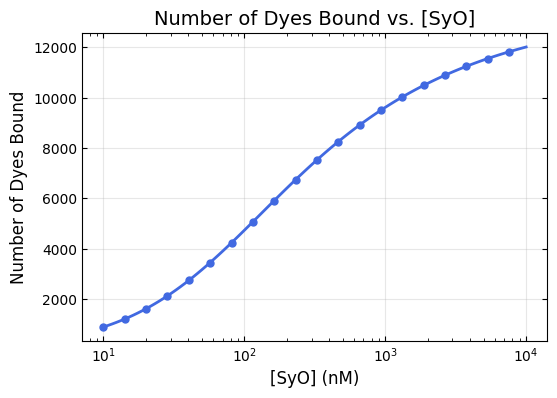

In [8]:
# Fixed parameters (from SYTOX Orange setup)
Nbp = 41364
Lk0 = Nbp / 10.5 # ~in this case 3940 turns
K = 2.4e6 # 1/M
n = 3 # bp/site
delta_Tw = 19.1 # deg/dye
deltaz_dye = 0.3 # nm/dye
C = 100 # nm
cons_DNA_exp = 1e-12 # M·bp (single-molecule)
kT = 4.1 # pN.nm
omega_tw = 0.2 # twist fraction
alpha = delta_Tw / 360.0 # turns unwound per bound dye
max_conc = 1e-4 # 100 μM; threshold for saturation note

# Compute_initial_conc with low-σ stability
def compute_initial_conc(target_sigma, final_conc):
    """
    Solve for initial [SyO] to achieve target_sigma at final_conc.
    Now robust down to σ = 0.00 and up to saturation.
    """
    target_DeltaLk = target_sigma * Lk0

    # SPECIAL CASE: σ = 0 → initial_conc = final_conc (equilibrated relaxed DNA)
    if abs(target_sigma) < 1e-6:
        return final_conc, 0, 0, 0.0, "Relaxed: initial = final [SyO]"

    # For small negative σ, use physics-based guess: N_open ≈ |target_DeltaLk| / alpha
    N_open_guess = max(0, -target_DeltaLk / alpha)  # dyes needed to induce ΔLk_topo
    gamma_guess = N_open_guess / Nbp
    # Inverse MvH approx: [SyO]_free ≈ gamma / (K * (1 - n*gamma))
    free_guess = gamma_guess / (K * (1 - n*gamma_guess)) if gamma_guess < 0.9/n else 1e-6
    initial_guess = (free_guess + gamma_guess * cons_DNA_exp) * 1e9 * 1.3  # nM, slight boost

    def objective(init_conc_nM):
        init_conc = init_conc_nM * 1e-9
        if init_conc <= 0:
            return 1e12
        gamma_open = mv_h_finite_conc_model(K, n, np.array([cons_DNA_exp]), init_conc)[0]
        N_open = gamma_open * Nbp
        DeltaLk_topo = -alpha * N_open
        try:
            N_final, _, Torque = plasmid_dye_binding_model(
                K, n, delta_Tw, deltaz_dye, Nbp, C, DeltaLk_topo, cons_DNA_exp, final_conc, 0
            )
        except:
            return 1e12
        DeltaLk_eff = DeltaLk_topo + alpha * N_final
        return DeltaLk_eff - target_DeltaLk

    # Use bounded solver with fallback
    from scipy.optimize import minimize_scalar
    try:
        sol = fsolve(objective, initial_guess, xtol=1e-3)
        init_nM = float(sol[0])
        if init_nM < 0 or init_nM > 1e8:  # >100 mM → invalid
            raise ValueError
    except:
        # Fallback: grid search in log space for low |σ|
        candidates = np.logspace(-2, 6, 200)  # 0.01 nM to 1 mM
        errors = np.abs([objective(c) for c in candidates])
        init_nM = candidates[np.argmin(errors)]

    init_conc = init_nM * 1e-9
    gamma_open = mv_h_finite_conc_model(K, n, np.array([cons_DNA_exp]), init_conc)[0]
    N_open = gamma_open * Nbp
    DeltaLk_topo = -alpha * N_open
    N_final, DeltaTw, Torque = plasmid_dye_binding_model(
        K, n, delta_Tw, deltaz_dye, Nbp, C, DeltaLk_topo, cons_DNA_exp, final_conc, 0
    )
    retention = N_final / N_open * 100 if N_open > 0 else 0
    notes = f"~{retention:.0f}% retention | γ_open = {gamma_open:.3f}"
    if init_nM > 1e5:
        notes += " | SATURATED"
    return init_conc, N_open, N_final, Torque, notes


# Plot number of dyes bound vs. SyO concentration
syto_concs_nM = np.logspace(1, 4, 100)  # 10 nM to 10,000 nM
syto_concs_M = syto_concs_nM * 1e-9

bound_dyes = np.zeros_like(syto_concs_nM)

for i, conc in enumerate(syto_concs_M):
    gamma = mv_h_finite_conc_model(K, n, np.array([cons_DNA_exp]), conc)[0]
    bound_dyes[i] = gamma * Nbp

plt.figure(figsize=(6, 4))
plt.plot(syto_concs_nM, bound_dyes, 'o-', color='royalblue', linewidth=2, markersize=5, markevery=5)
plt.xscale('log')
plt.xlabel('[SyO] (nM)', fontsize=12)
plt.ylabel('Number of Dyes Bound', fontsize=12)
plt.title('Number of Dyes Bound vs. [SyO]', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(direction='in', top=True, bottom=True, left=True, right=True)
plt.tick_params(axis='x', which='minor', bottom=True, top=True, direction='in')
plt.show()

In [9]:
# Compute for each sigma target
sigma_targets = [0.00, -0.02, -0.05, -0.08]
final_conc = 30e-9  # 20 nM

results = []
for sigma in sigma_targets:
    initial_conc_M, N_open, N_final, Torque, notes = compute_initial_conc(sigma, final_conc)
    target_DeltaLk = round(sigma * Lk0)
    initial_conc_nM = initial_conc_M * 1e9
    results.append({
        'Target σ': f"{sigma:.3f}",
        'Target ΔLk': target_DeltaLk,
        'Initial [SyO] (nM)': f"{initial_conc_nM:.1f}",
        'Pre-bound': f"{N_open:.0f}",
        'Final Bound': f"{N_final:.0f}",
        'Torque (pN·nm)': f"{Torque:+.1f}",
        'Notes': notes
    })

df = pd.DataFrame(results)


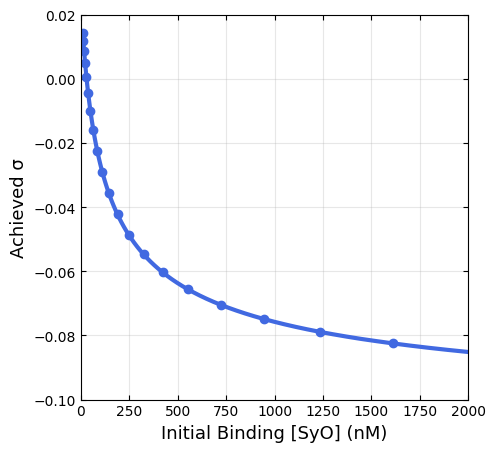

Initial (nM)  |  Achievd σ  |  Pre-bound  |  Final-bound  |  bp/dye
----------------------------------------------------------------------
      31     |     -0.000     |   2252      |     2218      |   18.65
      76     |     -0.020     |   4095      |     2618      |   15.80
     261     |     -0.050     |   7024      |     3319      |   12.46
    1301     |     -0.080     |   10005      |     4093      |   10.11


In [10]:
# Plot Achieved σ vs. Initial [SyO] at fixed 30 nM wash ===
final_conc_fixed = 30e-9  # 30 nM post-bound concentration

# Range of initial concentrations: 10 nM to 2000 nM (log-spaced for better resolution)
initial_concs_nM = np.logspace(1, 3.3, 100)  # 10 nM → ~2000 nM
initial_concs_M = initial_concs_nM * 1e-9

achieved_sigmas = np.zeros_like(initial_concs_nM)
pre_bound_dyes = np.zeros_like(initial_concs_nM)
final_bound_dyes = np.zeros_like(initial_concs_nM)

for i, init_c in enumerate(initial_concs_M):
    gamma_open = mv_h_finite_conc_model(K, n, np.array([cons_DNA_exp]), init_c)[0]
    N_open = gamma_open * Nbp
    DeltaLk_topo = -alpha * N_open
    N_final, _, _ = plasmid_dye_binding_model(
        K, n, delta_Tw, deltaz_dye, Nbp, C, DeltaLk_topo, cons_DNA_exp, final_conc_fixed, 0
    )
    DeltaLk_eff = DeltaLk_topo + alpha * N_final
    achieved_sigmas[i] = DeltaLk_eff / Lk0
    pre_bound_dyes[i] = N_open
    final_bound_dyes[i] = N_final

# Plot
plt.figure(figsize=(5, 5))
plt.plot(initial_concs_nM, achieved_sigmas, 'o-', color='royalblue', linewidth=3, markersize=6, markevery=5)
plt.xlabel('Initial Binding [SyO] (nM)', fontsize=13)
plt.ylabel('Achieved σ', fontsize=13)
plt.grid(True, alpha=0.3)
# plt.xscale('log')
plt.ylim(-0.10, 0.02)
plt.xlim(0, 2000)
plt.tick_params(direction='in', top=True, bottom=True, left=True, right=True)
# plt.xscale('log')
plt.show()

target_sigmas = [0, -0.02, -0.05, -0.08]

# Print quick lookup table with bp/dye column
# print("Quick Lookup: Initial [SyO] → Achieved σ (at 30 nM wash)")
print("Initial (nM)  |  Achievd σ  |  Pre-bound  |  Final-bound  |  bp/dye")
print("-" * 70)
for sig in target_sigmas:
    idx = np.argmin(np.abs(achieved_sigmas - sig))
    bp_per_dye = Nbp / final_bound_dyes[idx] if final_bound_dyes[idx] > 0 else float('inf')
    print(f"{initial_concs_nM[idx]:8.0f}     |     {achieved_sigmas[idx]:+.3f}     |   {pre_bound_dyes[idx]:.0f}      |     {final_bound_dyes[idx]:.0f}      |   {bp_per_dye:.2f}")

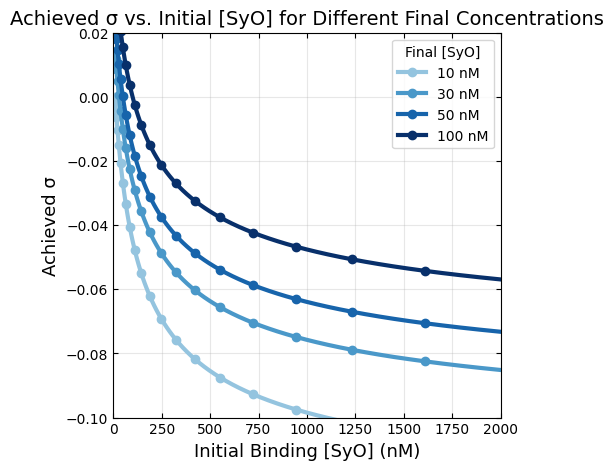

In [11]:
# Plot Achieved σ vs. Initial [SyO] for multiple final_conc_fixed values
final_conc_values = [10e-9, 30e-9, 50e-9, 100e-9]  # Different final concentrations
colors = plt.cm.Blues(np.linspace(0.4, 1, len(final_conc_values)))  # Shades of blue for each curve

# Range of initial concentrations: 10 nM to 2000 nM (log-spaced for better resolution)
initial_concs_nM = np.logspace(1, 3.3, 100)  # 10 nM → ~2000 nM
initial_concs_M = initial_concs_nM * 1e-9


plt.figure(figsize=(5, 5))

for final_conc_fixed, color in zip(final_conc_values, colors):
    achieved_sigmas = np.zeros_like(initial_concs_nM)
    pre_bound_dyes = np.zeros_like(initial_concs_nM)
    final_bound_dyes = np.zeros_like(initial_concs_nM)

    for i, init_c in enumerate(initial_concs_M):
        gamma_open = mv_h_finite_conc_model(K, n, np.array([cons_DNA_exp]), init_c)[0]
        N_open = gamma_open * Nbp
        DeltaLk_topo = -alpha * N_open
        N_final, _, _ = plasmid_dye_binding_model(
            K, n, delta_Tw, deltaz_dye, Nbp, C, DeltaLk_topo, cons_DNA_exp, final_conc_fixed, 0
        )
        DeltaLk_eff = DeltaLk_topo + alpha * N_final
        achieved_sigmas[i] = DeltaLk_eff / Lk0
        pre_bound_dyes[i] = N_open
        final_bound_dyes[i] = N_final

    # Plot for the current final_conc_fixed
    plt.plot(initial_concs_nM, achieved_sigmas, 'o-', color=color, linewidth=3, markersize=6, markevery=5, label=f'{final_conc_fixed*1e9:.0f} nM')

plt.xlabel('Initial Binding [SyO] (nM)', fontsize=13)
plt.ylabel('Achieved σ', fontsize=13)
plt.grid(True, alpha=0.3)
plt.ylim(-0.10, 0.02)
plt.xlim(0, 2000)
plt.tick_params(direction='in', top=True, bottom=True, left=True, right=True)
plt.legend(title='Final [SyO]', fontsize=10)
plt.title('Achieved σ vs. Initial [SyO] for Different Final Concentrations', fontsize=14)
plt.show()
